<a href="https://colab.research.google.com/github/kowsik005/ml_supervised_project/blob/main/Logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!

First 5 rows:
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0

Dataset shape:
(30, 3)

Column names:
['Unnamed: 0', 'YearsExperience', 'Salary']

Missing values:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

Dataset after removing index column:
   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0

Median Salary: 65238.0

Dataset with target:
   YearsExperience   Salary  HighSalary
0              1.2  39344.0           0
1              1.4  46206.0           0
2              1.6  37732.0           0
3              2.1  43526.0           0
4              2.3  39892.0           0

Input feature:
YearsExperience

Target:
HighSal

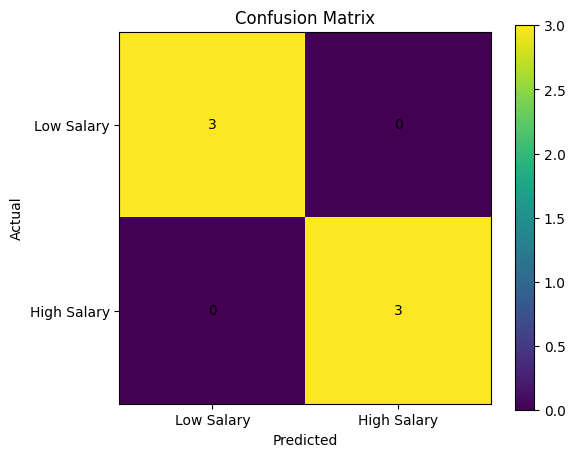

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


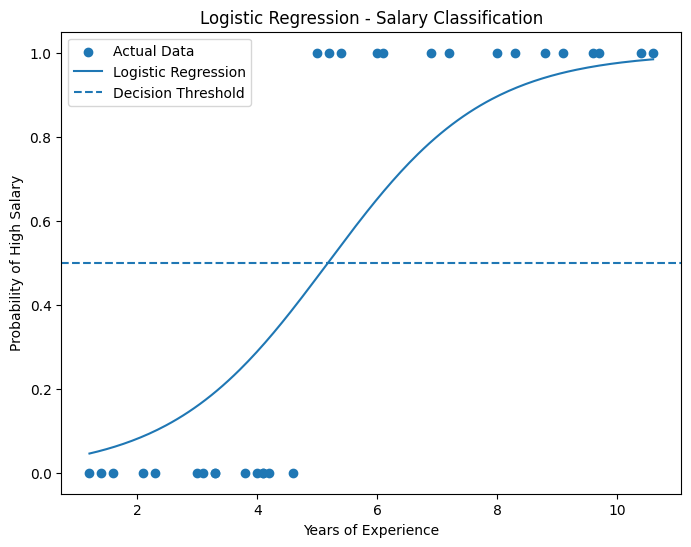


NEW EMPLOYEE PREDICTION
Years of Experience: 5
Prediction: LOW SALARY
Probability of High Salary: 46.6 %

Multiple Employee Predictions:
   YearsExperience   Prediction  HighSalaryProbability
0                1   Low Salary                   3.95
1                3   Low Salary                  15.92
2                5   Low Salary                  46.60
3                7  High Salary                  80.08
4               10  High Salary                  97.55


In [3]:
# ============================================================
# LOGISTIC REGRESSION - SALARY DATASET
# ============================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("Salary_dataset.csv")

print("Dataset loaded successfully!")

# ============================================================
# 3. DISPLAY DATASET
# ============================================================

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

# ============================================================
# 4. REMOVE UNNECESSARY COLUMN
# ============================================================

# Remove the index column
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

print("\nDataset after removing index column:")
print(df.head())

# ============================================================
# 5. CREATE BINARY TARGET
# ============================================================

# Calculate median salary
median_salary = df["Salary"].median()

print("\nMedian Salary:", median_salary)

# Salary greater than or equal to median = 1
# Salary below median = 0

df["HighSalary"] = (
    df["Salary"] >= median_salary
).astype(int)

print("\nDataset with target:")
print(df.head())

# ============================================================
# 6. DEFINE INPUT AND OUTPUT
# ============================================================

# Input feature
X = df[["YearsExperience"]]

# Target variable
y = df["HighSalary"]

print("\nInput feature:")
print("YearsExperience")

print("\nTarget:")
print("HighSalary")

# ============================================================
# 7. SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# 9. CREATE LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    random_state=42
)

# ============================================================
# 10. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression model trained successfully!")

# ============================================================
# 11. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_scaled)

# Probability predictions
y_probability = model.predict_proba(X_test_scaled)[:, 1]

print("\nActual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

print("\nPrediction probabilities:")
print(y_probability)

# ============================================================
# 12. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\n========================================")
print("LOGISTIC REGRESSION RESULTS")
print("========================================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Low Salary", "High Salary"]
    )
)

# ============================================================
# 15. PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Low Salary", "High Salary"]
)

plt.yticks(
    [0, 1],
    ["Low Salary", "High Salary"]
)

# Display values inside matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

# ============================================================
# 16. LOGISTIC REGRESSION CURVE
# ============================================================

# Create values for plotting
X_range = np.linspace(
    X["YearsExperience"].min(),
    X["YearsExperience"].max(),
    200
).reshape(-1, 1)

# Scale values
X_range_scaled = scaler.transform(X_range)

# Calculate probabilities
probabilities = model.predict_proba(
    X_range_scaled
)[:, 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    X["YearsExperience"],
    y,
    label="Actual Data"
)

plt.plot(
    X_range,
    probabilities,
    label="Logistic Regression"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Years of Experience")
plt.ylabel("Probability of High Salary")

plt.title(
    "Logistic Regression - Salary Classification"
)

plt.legend()
plt.show()

# ============================================================
# 17. PREDICT A NEW EMPLOYEE
# ============================================================

# Example: employee with 5 years experience
new_employee = pd.DataFrame({
    "YearsExperience": [5]
})

# Scale the new data
new_employee_scaled = scaler.transform(
    new_employee
)

# Predict class
prediction = model.predict(
    new_employee_scaled
)

# Predict probability
probability = model.predict_proba(
    new_employee_scaled
)[0][1]

print("\n========================================")
print("NEW EMPLOYEE PREDICTION")
print("========================================")

print("Years of Experience:", 5)

if prediction[0] == 1:
    print("Prediction: HIGH SALARY")
else:
    print("Prediction: LOW SALARY")

print(
    "Probability of High Salary:",
    round(probability * 100, 2),
    "%"
)

# ============================================================
# 18. TEST MULTIPLE EXPERIENCE VALUES
# ============================================================

experience_values = pd.DataFrame({
    "YearsExperience": [1, 3, 5, 7, 10]
})

experience_scaled = scaler.transform(
    experience_values
)

predictions = model.predict(
    experience_scaled
)

probabilities = model.predict_proba(
    experience_scaled
)[:, 1]

results = pd.DataFrame({
    "YearsExperience": experience_values[
        "YearsExperience"
    ],
    "Prediction": predictions,
    "HighSalaryProbability": probabilities
})

results["Prediction"] = results["Prediction"].map({
    0: "Low Salary",
    1: "High Salary"
})

results["HighSalaryProbability"] = (
    results["HighSalaryProbability"] * 100
).round(2)

print("\nMultiple Employee Predictions:")
print(results)

# ============================================================
# END OF PROGRAM
# ============================================================